# Multimodal Alzheimer's Disease Classification
### Fusing OASIS Clinical/Cognitive Features (Modality 1) with ResNet18 MRI Embeddings (Modality 2)

**Pipeline position:** Clinical CSV (Kaggle) + MRI Embeddings (Drive, from `mri_embeddings.csv`) → **Fuse on `subject_id`** → Preprocess → Train baseline classifiers → Evaluate

This notebook:
1. Downloads the OASIS Cross-Sectional clinical dataset directly from Kaggle.
2. Loads the 512-dim ResNet18 MRI embeddings CSV from Google Drive (produced by the previous embedding-extraction notebook).
3. Aligns `subject_id` formats between the two sources and merges on common subjects only.
4. Builds the final multimodal feature table and saves it as `final_multimodal_dataset.csv`.
5. Preprocesses (missing values → label encoding → scaling).
6. Trains three baseline multimodal classifiers: Logistic Regression, Random Forest, XGBoost.
7. Evaluates each with Accuracy, Precision, Recall, F1, Macro-F1, and a Confusion Matrix.

> **Note on the target label:** the MRI-embedding pipeline already encodes a 3-class diagnostic label (`label`) that was used to train the upstream ResNet18 and is consistent with the rest of this project's pipeline (CNN → embeddings → GCN). We use that column as the **classification target** for the fused model, and keep the clinical `Group`/`CDR` columns as **input features**. This avoids mixing two different labeling schemes as the target and keeps the target consistent with the rest of your pipeline. If you'd rather predict the clinical `Group` label instead, see the commented alternative in the "Build Final Multimodal Dataset" section below.


## 1. Setup: Install Packages

In [45]:
!pip install -q kaggle xgboost scikit-learn pandas numpy matplotlib seaborn

## 2. Kaggle Authentication

Set your Kaggle API token below. You can get one from `kaggle.com/settings → API`.
This mirrors the auth approach already used in your MRI-embedding notebook.

In [46]:
import os

# Replace with your own Kaggle API token (kaggle.com -> Settings -> API)
os.environ["KAGGLE_API_TOKEN"] = "KGAT_283606f7db27511d5bedbdc1c43c0695"




## 3. Load Modality 1 — OASIS Cross-Sectional Clinical Dataset (Kaggle)

We pull this directly from Kaggle (`jboysen/mri-and-alzheimers`, which contains
`oasis_cross-sectional.csv`). If your account has a different/forked copy of the
dataset, change `KAGGLE_DATASET_REF` below.

In [47]:
KAGGLE_DATASET_REF = "jboysen/mri-and-alzheimers"

!kaggle datasets download -d {KAGGLE_DATASET_REF} -p /content/oasis_clinical --unzip

Dataset URL: https://www.kaggle.com/datasets/jboysen/mri-and-alzheimers
License(s): CC0-1.0
100% 12.6k/12.6k [00:00<00:00, 26.7MB/s]



In [48]:
import glob

# Locate the cross-sectional CSV regardless of exact filename casing
candidates = glob.glob("/content/oasis_clinical/**/*cross*sectional*.csv", recursive=True)
if not candidates:
    candidates = glob.glob("/content/oasis_clinical/**/*.csv", recursive=True)

print("CSV files found:")
for c in candidates:
    print(" -", c)

CLINICAL_CSV_PATH = candidates[0]
print("\nUsing:", CLINICAL_CSV_PATH)

CSV files found:
 - /content/oasis_clinical/oasis_cross-sectional.csv

Using: /content/oasis_clinical/oasis_cross-sectional.csv


In [49]:
import pandas as pd
import numpy as np

clinical_df = pd.read_csv(CLINICAL_CSV_PATH)
print("Clinical dataset shape:", clinical_df.shape)
clinical_df.head()

Clinical dataset shape: (436, 12)


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


In [50]:
clinical_df.info()
print()
print("Missing values per column:")
print(clinical_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      436 non-null    object 
 1   M/F     436 non-null    object 
 2   Hand    436 non-null    object 
 3   Age     436 non-null    int64  
 4   Educ    235 non-null    float64
 5   SES     216 non-null    float64
 6   MMSE    235 non-null    float64
 7   CDR     235 non-null    float64
 8   eTIV    436 non-null    int64  
 9   nWBV    436 non-null    float64
 10  ASF     436 non-null    float64
 11  Delay   20 non-null     float64
dtypes: float64(7), int64(2), object(3)
memory usage: 41.0+ KB

Missing values per column:
ID         0
M/F        0
Hand       0
Age        0
Educ     201
SES      220
MMSE     201
CDR      201
eTIV       0
nWBV       0
ASF        0
Delay    416
dtype: int64


### 3.1 Standardize Clinical Columns

The Kaggle copy commonly uses columns like `ID`, `M/F`, `Educ`. We rename to the
schema you described (`Age`, `Gender`, `EDUC`, `SES`, `MMSE`, `CDR`, `eTIV`,
`nWBV`, `ASF`, `Group`) and align `subject_id` so it can be merged with the MRI
embeddings.

In [51]:
rename_map = {
    "ID": "Subject_ID",
    "M/F": "Gender",
    "Educ": "EDUC",
    "EDUC": "EDUC",
    "SES": "SES",
    "Age": "Age",
    "MMSE": "MMSE",
    "CDR": "CDR",
    "eTIV": "eTIV",
    "nWBV": "nWBV",
    "ASF": "ASF",
}
clinical_df = clinical_df.rename(columns={k: v for k, v in rename_map.items() if k in clinical_df.columns})

# If a 'Group' column doesn't exist in this Kaggle copy, derive it from CDR
# (standard OASIS convention: CDR 0 -> Nondemented, CDR > 0 -> Demented)
if "Group" not in clinical_df.columns:
    if "CDR" in clinical_df.columns:
        def cdr_to_group(cdr):
            if pd.isna(cdr):
                return np.nan
            return "Nondemented" if cdr == 0 else "Demented"

        clinical_df["Group"] = clinical_df["CDR"].apply(cdr_to_group)
        print("Derived 'Group' column from CDR (CDR==0 -> Nondemented, else Demented).")
    else:
        print("WARNING: No 'Group' or 'CDR' column found — check the dataset schema above.")

print(clinical_df.columns.tolist())
clinical_df.head()

Derived 'Group' column from CDR (CDR==0 -> Nondemented, else Demented).
['Subject_ID', 'Gender', 'Hand', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay', 'Group']


,Subject_ID,Gender,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,Group
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN,Nondemented
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN,Nondemented
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN,Demented
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN,NaN


In [52]:
import re

# OASIS clinical IDs look like 'OAS1_0001_MR1'; the MRI-embedding pipeline keys
# on 'OAS1_0001'. Extract the matching subject pattern so the two modalities
# can be merged on a common key.
subject_pattern = re.compile(r"(OAS\d+_\d+)", re.IGNORECASE)

def extract_subject_id(raw_id):
    if pd.isna(raw_id):
        return None
    match = subject_pattern.search(str(raw_id))
    return match.group(1) if match else str(raw_id)

clinical_df["subject_id"] = clinical_df["Subject_ID"].apply(extract_subject_id)

print("Unique subject_ids in clinical data:", clinical_df["subject_id"].nunique())
clinical_df[["Subject_ID", "subject_id"]].head()

Unique subject_ids in clinical data: 416


,Subject_ID,subject_id
0,OAS1_0001_MR1,OAS1_0001
1,OAS1_0002_MR1,OAS1_0002
2,OAS1_0003_MR1,OAS1_0003
3,OAS1_0004_MR1,OAS1_0004
4,OAS1_0005_MR1,OAS1_0005


## 4. Load Modality 2 — MRI Embeddings (Google Drive)

These come from your earlier ResNet18 embedding-extraction notebook
(`mri_embeddings.csv`: `subject_id`, `label`, `emb_0` … `emb_511`).

In [53]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/alzheimer_project"
EMBEDDINGS_CSV = f"{PROJECT_DIR}/mri_embeddings.csv"

import os
print("Embeddings file exists:", os.path.exists(EMBEDDINGS_CSV))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Embeddings file exists: True


In [54]:
mri_df = pd.read_csv(EMBEDDINGS_CSV)
emb_cols = [c for c in mri_df.columns if c.startswith("emb_")]

print("MRI embeddings shape:", mri_df.shape)
print("Number of embedding dims:", len(emb_cols))
print("Unique subjects:", mri_df["subject_id"].nunique())
print("\nLabel distribution:")
print(mri_df["label"].value_counts())
mri_df[["subject_id", "label"] + emb_cols[:5]].head()

MRI embeddings shape: (347, 514)
Number of embedding dims: 512
Unique subjects: 347

Label distribution:
label
Non Demented          266
Very mild Dementia     58
Dementia               23
Name: count, dtype: int64


,subject_id,label,emb_0,emb_1,emb_2,emb_3,emb_4
0,OAS1_0351,Dementia,2.166160,1.735637,1.416839,0.433220,0.828611
1,OAS1_0308,Dementia,0.638422,0.964953,0.859017,1.198233,0.738115
2,OAS1_0053,Dementia,1.749306,1.919430,1.905636,1.816800,0.898333
3,OAS1_0223,Dementia,0.814133,0.930930,1.099241,1.426746,0.522730
4,OAS1_0373,Dementia,0.519155,0.637669,0.420800,0.719033,0.297324


In [55]:
print("Missing values in embeddings:", mri_df[emb_cols].isna().sum().sum())
print("Duplicate subject_ids in MRI data:", mri_df["subject_id"].duplicated().sum())

Missing values in embeddings: 0
Duplicate subject_ids in MRI data: 0


## 5. Match Subjects Across Modalities

Keep only subjects present in **both** the clinical dataset and the MRI
embeddings.

In [56]:
clinical_ids = set(clinical_df["subject_id"].dropna())
mri_ids = set(mri_df["subject_id"].dropna())

common_ids = clinical_ids & mri_ids

print(f"Clinical subjects : {len(clinical_ids)}")
print(f"MRI subjects       : {len(mri_ids)}")
print(f"Common subjects     : {len(common_ids)}")
print(f"Clinical-only       : {len(clinical_ids - mri_ids)}")
print(f"MRI-only            : {len(mri_ids - clinical_ids)}")

Clinical subjects : 416
MRI subjects       : 347
Common subjects     : 347
Clinical-only       : 69
MRI-only            : 0


In [57]:
clinical_common = clinical_df[clinical_df["subject_id"].isin(common_ids)].copy()
mri_common = mri_df[mri_df["subject_id"].isin(common_ids)].copy()

# Guard against duplicate subject rows before merging (keep first occurrence)
clinical_common = clinical_common.drop_duplicates(subset="subject_id", keep="first")
mri_common = mri_common.drop_duplicates(subset="subject_id", keep="first")

print("Clinical (common only):", clinical_common.shape)
print("MRI (common only):     ", mri_common.shape)

Clinical (common only): (347, 14)
MRI (common only):      (347, 514)


## 6. Build Final Multimodal Dataset

Merge both modalities on `subject_id` (inner join, since we already filtered to
common subjects). The MRI pipeline's `label` column is used as the
classification **target**; clinical columns (including `Group`/`CDR`) and all
512 embedding dimensions are used as **features**.

```python
# Alternative: if you'd rather predict the clinical 'Group' label instead,
# swap the TARGET_COL below to "Group" and drop/rename 'label' accordingly.
```


In [58]:
TARGET_COL = "label"   # MRI pipeline's diagnostic label (3-class, used as final target)

final_df = mri_common.merge(clinical_common, on="subject_id", how="inner")

print("Final multimodal dataset shape:", final_df.shape)
print("\nColumns:", final_df.columns.tolist()[:15], "...")
print("\nTarget distribution:")
print(final_df[TARGET_COL].value_counts())
final_df.head()

Final multimodal dataset shape: (347, 527)

Columns: ['subject_id', 'label', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12'] ...

Target distribution:
label
Non Demented          266
Very mild Dementia     58
Dementia               23
Name: count, dtype: int64


,subject_id,label,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,...,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,Group
0,OAS1_0351,Dementia,2.166160,1.735637,1.416839,0.433220,0.828611,0.160828,1.113162,3.225832,...,86,1.0,4.0,15.0,2.0,1512,0.665,1.161,NaN,Demented
1,OAS1_0308,Dementia,0.638422,0.964953,0.859017,1.198233,0.738115,0.505283,0.717653,1.097480,...,78,3.0,3.0,15.0,2.0,1401,0.703,1.253,NaN,Demented
2,OAS1_0053,Dementia,1.749306,1.919430,1.905636,1.816800,0.898333,0.061637,0.696262,1.961840,...,83,1.0,4.0,21.0,1.0,1384,0.699,1.268,NaN,Demented
3,OAS1_0223,Dementia,0.814133,0.930930,1.099241,1.426746,0.522730,0.215527,0.416776,0.994693,...,84,2.0,NaN,20.0,1.0,1641,0.703,1.070,NaN,Demented
4,OAS1_0373,Dementia,0.519155,0.637669,0.420800,0.719033,0.297324,0.724963,0.287697,0.517278,...,80,3.0,2.0,20.0,1.0,1732,0.692,1.013,NaN,Demented


## 7. Preprocessing

### 7.1 Missing Value Handling

In [59]:
print("Missing values per column (top 15):")
print(final_df.isna().sum().sort_values(ascending=False).head(15))

Missing values per column (top 15):
Delay      347
SES        165
Group      147
CDR        147
MMSE       147
EDUC       147
emb_342      0
emb_344      0
emb_345      0
emb_346      0
emb_347      0
emb_348      0
emb_349      0
emb_350      0
emb_351      0
dtype: int64


In [60]:
clinical_numeric_cols = [c for c in ["Age", "EDUC", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF"]
                          if c in final_df.columns]

# Numeric clinical columns -> median imputation
for col in clinical_numeric_cols:
    if final_df[col].isna().any():
        median_val = final_df[col].median()
        final_df[col] = final_df[col].fillna(median_val)
        print(f"Filled {col} missing values with median={median_val}")

# Categorical clinical columns -> mode imputation
categorical_cols = [c for c in ["Gender", "Hand"] if c in final_df.columns]
for col in categorical_cols:
    if final_df[col].isna().any():
        mode_val = final_df[col].mode()[0]
        final_df[col] = final_df[col].fillna(mode_val)
        print(f"Filled {col} missing values with mode={mode_val}")

# Embedding columns should have no NaNs, but guard anyway
final_df[emb_cols] = final_df[emb_cols].fillna(0)

print("\nRemaining missing values:", final_df.isna().sum().sum())

Filled EDUC missing values with median=3.0
Filled SES missing values with median=2.0
Filled MMSE missing values with median=29.0
Filled CDR missing values with median=0.0

Remaining missing values: 494


### 7.2 Label Encoding

In [61]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

# Encode Gender (categorical clinical feature)
if "Gender" in final_df.columns:
    le_gender = LabelEncoder()
    final_df["Gender_enc"] = le_gender.fit_transform(final_df["Gender"].astype(str))
    encoders["Gender"] = le_gender
    print("Gender classes:", list(le_gender.classes_))

# Encode the target label
le_target = LabelEncoder()
final_df["target_enc"] = le_target.fit_transform(final_df[TARGET_COL].astype(str))
encoders["target"] = le_target
print("Target classes:", list(le_target.classes_))

final_df[[TARGET_COL, "target_enc"]].drop_duplicates()

Gender classes: ['F', 'M']
Target classes: ['Dementia', 'Non Demented', 'Very mild Dementia']


/tmp/ipykernel_910/2587193118.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df["Gender_enc"] = le_gender.fit_transform(final_df["Gender"].astype(str))
/tmp/ipykernel_910/2587193118.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df["target_enc"] = le_target.fit_transform(final_df[TARGET_COL].astype(str))


,label,target_enc
0,Dementia,0
23,Very mild Dementia,2
81,Non Demented,1


### 7.3 Feature Scaling

In [62]:
# --- Fix: remove CDR from features (it deterministically encodes the target) ---

clinical_numeric_cols = [c for c in ["Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF"]
                          if c in final_df.columns]
# NOTE: "CDR" intentionally excluded — crosstab confirmed it's a 1:1 encoding of the target label.

feature_cols = clinical_numeric_cols + (["Gender_enc"] if "Gender_enc" in final_df.columns else []) + emb_cols

X = final_df[feature_cols].copy()
y = final_df["target_enc"].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)

print("Feature matrix shape (CDR removed):", X_scaled.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Feature matrix shape (CDR removed): (347, 520)
Train shape: (277, 520)
Test shape:  (70, 520)


In [63]:
from sklearn.preprocessing import StandardScaler

feature_cols = clinical_numeric_cols + (["Gender_enc"] if "Gender_enc" in final_df.columns else []) + emb_cols

X = final_df[feature_cols].copy()
y = final_df["target_enc"].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)

print("Feature matrix shape:", X_scaled.shape)
X_scaled.head()


Feature matrix shape: (347, 520)


,Age,EDUC,SES,MMSE,eTIV,nWBV,ASF,Gender_enc,emb_0,emb_1,...,emb_502,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511
0,1.314657,-2.142353,2.078461,-4.297361,0.198005,-2.024962,-0.306826,1.238082,4.330030,2.847728,...,4.429397,4.505575,-2.035312,2.740099,-2.424524,2.623105,-1.390973,2.689764,-1.785979,-1.300591
1,0.995869,-0.097246,0.886352,-4.297361,-0.493559,-1.399701,0.402143,-0.807701,0.853578,1.286640,...,0.838823,-0.597694,-1.237803,1.121489,-1.406166,1.284864,-1.172184,0.735795,-1.251917,-1.265608
2,1.195111,-2.142353,2.078461,-2.300685,-0.599474,-1.465518,0.517735,-0.807701,3.381456,3.220018,...,2.258632,1.938234,-2.058395,3.675835,-2.482955,3.587341,-1.345040,4.096745,-1.901636,-1.418109
3,1.234960,-1.119800,-0.305757,-2.633464,1.001715,-1.399701,-1.008088,1.238082,1.253418,1.217724,...,0.964350,1.151679,-1.807888,1.463791,-1.624723,1.461173,-1.284402,1.464687,-1.365744,-1.461074
4,1.075566,-0.097246,-0.305757,-2.633464,1.568673,-1.580697,-1.447340,-0.807701,0.582179,0.623698,...,0.296904,0.291082,-1.004299,0.670947,-1.014812,0.526582,-1.514351,0.127215,-0.548506,-1.622239


In [64]:
print("Shape:", X_scaled.shape)

print("\nTarget Distribution:")
print(y.value_counts())

print("\nColumns:", len(feature_cols))


Shape: (347, 520)

Target Distribution:
target_enc
1    266
2     58
0     23
Name: count, dtype: int64

Columns: 520


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(y_train.value_counts())
print(y_test.value_counts())

target_enc
1    212
2     46
0     19
Name: count, dtype: int64
target_enc
1    54
2    12
0     4
Name: count, dtype: int64


## 8. Save Final Multimodal Dataset

Save the merged, pre-scaling dataset (raw + encoded columns) so it can be
reused outside this notebook (e.g. by the GCN stage).

In [66]:
OUTPUT_PATH = f"{PROJECT_DIR}/final_multimodal_dataset.csv"

final_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")
print(f"Shape: {final_df.shape}")

Saved: /content/drive/MyDrive/alzheimer_project/final_multimodal_dataset.csv
Shape: (347, 529)


In [67]:
import os
print(os.path.exists(f"{PROJECT_DIR}/final_multimodal_dataset.csv"))
# Should print: True

True


## 9. Train/Test Split

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (277, 520)
Test shape:  (70, 520)


## 10. Train Baseline Multimodal Models

Logistic Regression, Random Forest, and XGBoost — all trained on the fused
clinical + embedding feature matrix.

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        random_state=42,
        eval_metric="mlogloss",
        use_label_encoder=False,
    ),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Random Forest


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:51:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Trained: XGBoost


## 11. Evaluate Models

Accuracy, Precision, Recall, F1-score (weighted), Macro-F1, and Confusion
Matrix for every model.

In [70]:
# --- Diagnostic: check for leakage and class balance before trusting results ---

print("Total subjects in final_df:", len(final_df))
print("Unique subject_ids:", final_df["subject_id"].nunique())
print()

# 1. Class balance — small/imbalanced test sets can fake perfect scores
print("Target class distribution (label):")
print(final_df[TARGET_COL].value_counts())
print()
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print("Test set class counts:")
print(y_test.value_counts())
print()

# 2. CDR vs label relationship — does CDR alone basically determine the target?
if "CDR" in final_df.columns:
    print("Crosstab: CDR vs target label")
    print(pd.crosstab(final_df["CDR"], final_df[TARGET_COL]))
    print()

# 3. Quick leakage probe — how well does CDR ALONE predict the target?
if "CDR" in final_df.columns:
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.model_selection import cross_val_score

    X_cdr_only = final_df[["CDR"]].fillna(final_df["CDR"].median())
    y_full = final_df["target_enc"]

    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    scores = cross_val_score(clf, X_cdr_only, y_full, cv=5)
    print(f"CV accuracy using ONLY 'CDR' as a feature: {scores.mean():.3f} (+/- {scores.std():.3f})")
    print("If this is near 1.0, CDR is leaking the target almost perfectly.")

Total subjects in final_df: 347
Unique subject_ids: 347

Target class distribution (label):
label
Non Demented          266
Very mild Dementia     58
Dementia               23
Name: count, dtype: int64

Train size: 277, Test size: 70
Test set class counts:
target_enc
1    54
2    12
0     4
Name: count, dtype: int64

Crosstab: CDR vs target label
label  Dementia  Non Demented  Very mild Dementia
CDR                                              
0.0           0           266                   0
0.5           0             0                  58
1.0          21             0                   0
2.0           2             0                   0

CV accuracy using ONLY 'CDR' as a feature: 1.000 (+/- 0.000)
If this is near 1.0, CDR is leaking the target almost perfectly.



===== Logistic Regression =====
                    precision    recall  f1-score   support

          Dementia       0.60      0.75      0.67         4
      Non Demented       0.94      0.94      0.94        54
Very mild Dementia       0.82      0.75      0.78        12

          accuracy                           0.90        70
         macro avg       0.79      0.81      0.80        70
      weighted avg       0.90      0.90      0.90        70



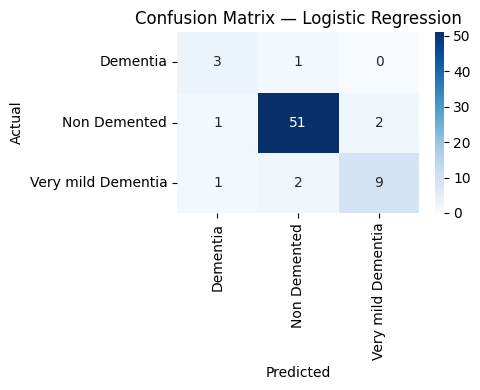


===== Random Forest =====
                    precision    recall  f1-score   support

          Dementia       0.75      0.75      0.75         4
      Non Demented       0.95      0.96      0.95        54
Very mild Dementia       0.91      0.83      0.87        12

          accuracy                           0.93        70
         macro avg       0.87      0.85      0.86        70
      weighted avg       0.93      0.93      0.93        70



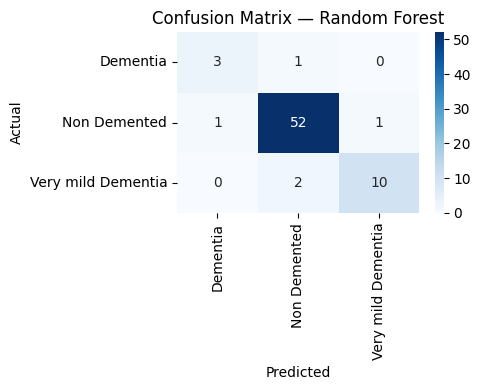


===== XGBoost =====
                    precision    recall  f1-score   support

          Dementia       0.75      0.75      0.75         4
      Non Demented       0.95      0.96      0.95        54
Very mild Dementia       0.91      0.83      0.87        12

          accuracy                           0.93        70
         macro avg       0.87      0.85      0.86        70
      weighted avg       0.93      0.93      0.93        70



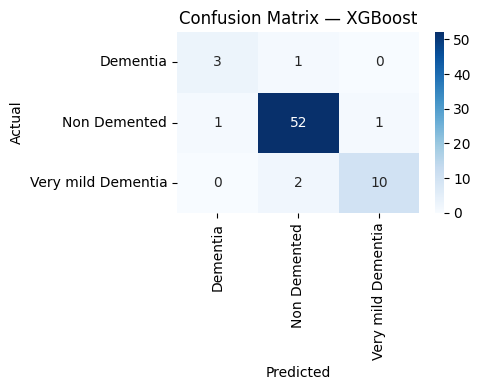

In [71]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Macro-F1": macro_f1,
    })

    print(f"\n===== {name} =====")
    print(classification_report(
        y_test, y_pred,
        target_names=[str(c) for c in le_target.classes_],
        zero_division=0,
    ))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=le_target.classes_, yticklabels=le_target.classes_
    )
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

### 11.1 Model Comparison Summary

In [72]:
results_df = pd.DataFrame(results).sort_values("Macro-F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-score,Macro-F1
0,Random Forest,0.928571,0.928052,0.928571,0.927967,0.857898
1,XGBoost,0.928571,0.928052,0.928571,0.927967,0.857898
2,Logistic Regression,0.900000,0.903117,0.900000,0.900828,0.797907


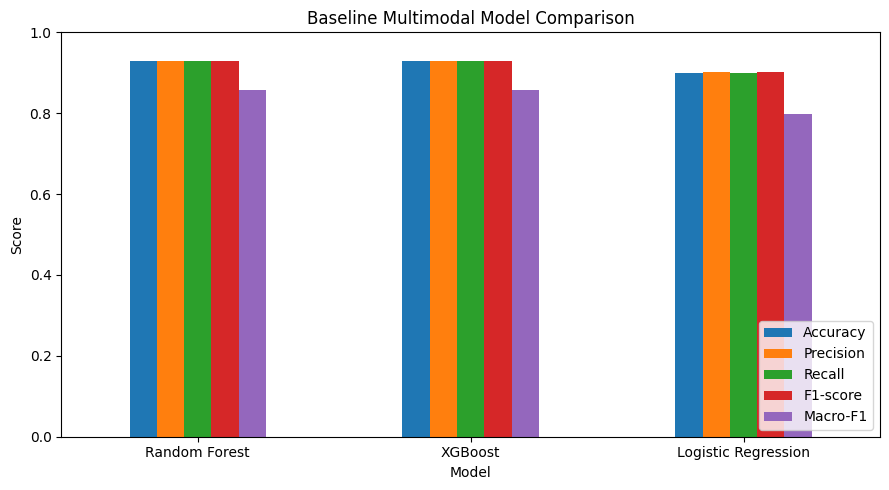

In [73]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score", "Macro-F1"]].plot(
    kind="bar", figsize=(9, 5)
)
plt.title("Baseline Multimodal Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 12. Summary

- **Modality 1 (clinical)** was pulled directly from Kaggle and standardized to a common `subject_id` format.
- **Modality 2 (MRI embeddings)** was loaded from `mri_embeddings.csv` in Google Drive.
- Only subjects present in **both** modalities were kept, producing the fused `final_multimodal_dataset.csv`.
- Three baseline classifiers were trained on the fused 520+ dimensional feature space (clinical + 512-dim embeddings).
- Compare `results_df` above to choose the strongest baseline, and use it as your reference point before moving to the GCN stage.
